(blue_stragglers_ntbk)=

# Blue Stragglers

This tutorial shows how we can use methods available in the [Synthetic](asteca.Synthetic) class to estimate per-star probabilities of being a blue straggler for a given observed cluster.

We start by loading the cluster file and a set of isochrones, and instantiating a synthetic object which we calibrate with the cluster's data:

In [9]:
import asteca
import pandas as pd
import numpy as np

obs_df = pd.read_csv("../_static/cluster_bss.csv")

# Load cluster file
my_cluster = asteca.Cluster(
    ra=obs_df["RA_ICRS"],
    dec=obs_df["DE_ICRS"], 
    mag=obs_df["Gmag"],
    e_mag=obs_df["e_Gmag"],
    color=obs_df["BP-RP"],
    e_color=obs_df["e_BP-RP"],
    verbose=2
)

# Load isochrones
isochs = asteca.Isochrones(
    model='parsec',
    isochs_path="../_static/parsec/",
    mag="Gmag",
    color=("G_BPmag", "G_RPmag"),
    magnitude_effl=6390.7,
    color_effl=(5182.58, 7825.08),
    verbose=2
)

# Create Synthetic cluster object
synthcl = asteca.Synthetic(isochs, seed=457304, verbose=2)

# Calibrate the `synthcl` object
synthcl.calibrate(my_cluster)


Instantiating cluster from data
Columns read   : ra, dec, mag, e_mag, color, e_color
N_stars        : 1428
N_clust_min    : 25
N_clust_max    : 2000
Cluster object generated

Instantiating isochrones
Model          : PARSEC
N_files        : 1
N_mets         : 3
N_ages         : 11
N_points       : 2000
z    range     : [0.01, 0.02]
loga range     : [7.0, 9.5]
Magnitude      : Gmag
Color          : G_BPmag-G_RPmag
Isochrone object generated

Instantiating synthetic
Default params : {'met': 0.0152, 'loga': 8.0, 'alpha': 0.09, 'beta': 0.94, 'Rv': 3.1, 'DR': 0.0, 'Av': 0.2, 'dm': 9.0}
Extinction law : CCMO
Diff reddening : uniform
IMF            : chabrier_2014
Max init mass  : 10000
Gamma dist     : D&K
Random seed    : 457304
Synthetic clusters object generated

Calibrated observed cluster
N_stars_obs    : 1428
Max magnitude  : 18.99
Error distribution loaded


After this, we call the [get_models()](asteca.Synthetic.get_models) method. This method requires two arguments: `model` which is a dictionary of parameters and a `model_std` dictionary which contains the uncertainties (standard deviations) associated to each parameter in the `model` dictionary. This information can be obtained by fitting an observed cluster as described in the [Parameters fit with pyABC](paramfit) tutorial.

In [12]:
# Define mean and STDDEv params for the observed cluster
model_means = {
    "loga": 8.1,
    "dm": 8.3,
    "Av": 0.5,
}
model_std = {
    "loga": 0.05,
    "dm": 0.02,
    "Av": 0.02,
}

# Sample models
synthcl.get_models(model_means, model_std)


Generate synthetic models
N_models       : 200
Attributes stored in Synthetic object


Finally, we obtain the BSSs probabilities calling [bss_probabilities()](asteca.Synthetic.bss_probabilities) method:

In [13]:
# Obtain BSS probabilities
bss_probs = synthcl.bss_probabilities()


Blue straggler probabilities estimated


We can check the number of detected BSSs using a probability cut of P=50%:

In [14]:
msk_bss = bss_probs > 0.5
print(f"Number of BSSs detected:{msk.sum()}")

Number of BSSs detected:21


A simple plot shows which observed stars are more likely to be BSSs:

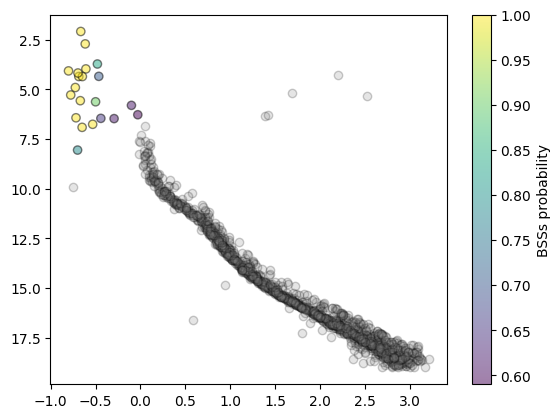

In [17]:
import matplotlib.pyplot as plt
plt.scatter(my_cluster.color[~msk_bss], my_cluster.mag[~msk_bss], alpha=0.2, ec="k", c="grey")
plt.scatter(my_cluster.color[msk_bss], my_cluster.mag[msk_bss], alpha=0.5, ec="k", c=bss_probs[msk_bss])
cbar = plt.colorbar()
cbar.set_label("BSSs probability")
plt.gca().invert_yaxis();